In [1]:
import sys
import os
from pathlib import Path

notebook_path = Path.cwd()

ROOT = notebook_path.parent.parent
print(ROOT)
RAFT_PATH = ROOT / "external" / "RAFT-Stereo"
os.chdir(ROOT)
if str(RAFT_PATH) not in sys.path:
    sys.path.append(str(ROOT))

/srv/homes/onbo10/thesis_main


In [2]:
from src.Stereo_matching.inference.RAFT_Stereo_inferencer import RAFTSTEREOInferencer
import yaml
from src.Geometry.triangulation.triangulator import Triangulator
import cv2
from src.Geometry.triangulation.triangulation_utils import *
import matplotlib.pyplot as plt

/srv/homes/onbo10/.conda/envs/raftstereo/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
raft_model= 'external/RAFT-Stereo/models/raftstereo-middlebury.pth'

In [4]:
left_mask_path = "data/Surgpose_for_segmentation/left_test_set/binary_masks/vid_000004_left_frame_000273.png"
frame_id= os.path.basename(left_mask_path).split('.')[0]
right_mask_path = left_mask_path.replace('left', 'right')
zip_calib_path = "data/SurgPose/SurgPose_for_HRNet/000004.zip"
left_img_path = "data/SurgPose/SurgPose_for_HRNet/Extracted/extracted_frames/000004/vid_000004_left_frame_000273.jpg"
right_img_path = "data/SurgPose/SurgPose_for_HRNet/Extracted_right_test/extracted_frames/000004/vid_000004_right_frame_000273.jpg"

In [5]:
#Initialize Tools
triangulator = Triangulator()
triangulator.load_calibration(zip_calib_path)

#Load Masks
mask_l = cv2.imread(left_mask_path, cv2.IMREAD_GRAYSCALE)
mask_r = cv2.imread(right_mask_path, cv2.IMREAD_GRAYSCALE)
img_l = cv2.imread(left_img_path)
img_r= cv2.imread(right_img_path)
h, w = img_l.shape[:2]


In [6]:
mode = "conventional"
lmap1, lmap2, rmap1, rmap2, q= triangulator.get_rectification_maps(img_size=(h,w), mode=mode)
rect_l, rect_r = triangulator.rectify_images(img_l, img_r,lmap1, lmap2, rmap1, rmap2, mode)
rect_mask_l = cv2.remap(mask_l, lmap1, lmap2, cv2.INTER_NEAREST)
rect_mask_r = cv2.remap(mask_r, rmap1, rmap2, cv2.INTER_NEAREST)


In [7]:

inferencer = RAFTSTEREOInferencer(raft_model, device='cuda')

In [8]:
# Get both maps
disp_l, disp_r = inferencer.get_bidirectional_disparity(rect_l, rect_r)

# Check consistency
lrc_mask, lrc_error = inferencer.compute_lrc_mask(disp_l, disp_r)

/srv/homes/onbo10/.conda/envs/raftstereo/lib/python3.7/site-packages/torch/functional.py:568: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  /opt/conda/conda-bld/pytorch_1646755953518/work/aten/src/ATen/native/TensorShape.cpp:2228.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


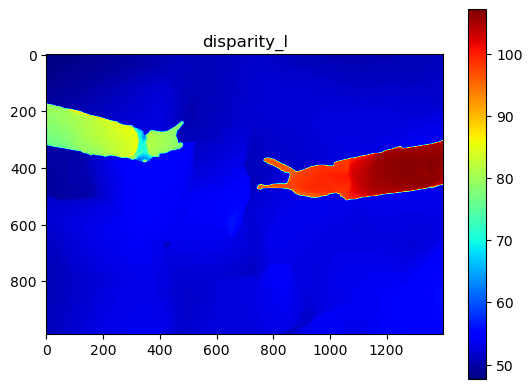

In [9]:
plt.imshow(disp_l,cmap='jet')
plt.title('disparity_l')
plt.colorbar()


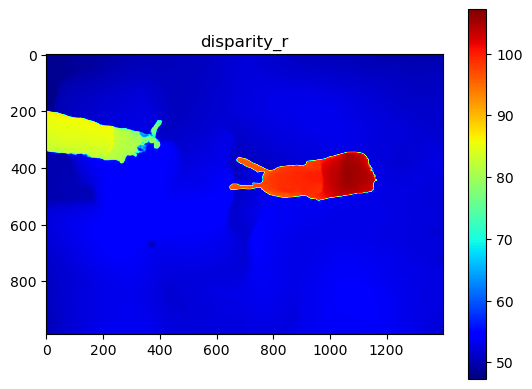

In [10]:
plt.imshow(disp_r,cmap='jet')
plt.title('disparity_r')
plt.colorbar()

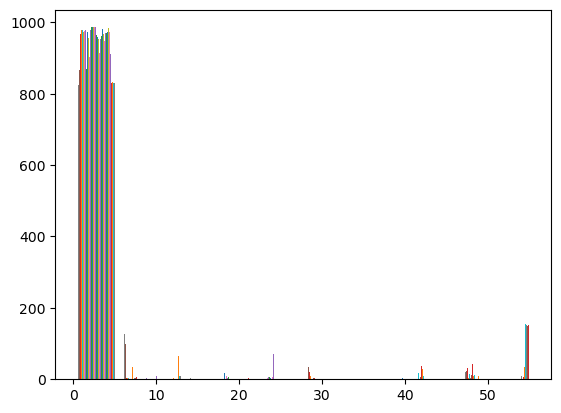

In [11]:
plt.hist(lrc_error)
plt.show()

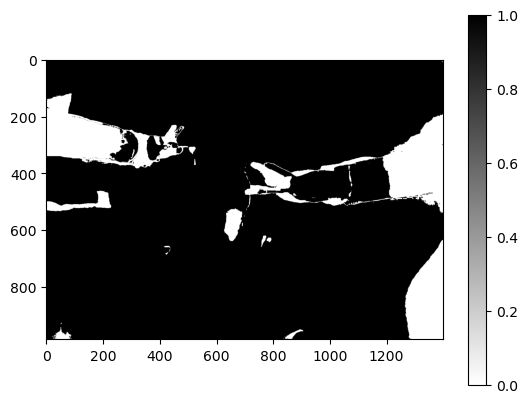

In [12]:
plt.imshow(lrc_mask, cmap='binary')
plt.colorbar()


In [13]:
points_3d_cloud, colors, disparity = triangulator.project_disparity_to_3d(disp_l*lrc_mask, q, rect_l, rect_mask_l)

In [14]:
from utilities.visualizer_triangulation import TriangulationVisualizer
visualizer = TriangulationVisualizer()
visualizer.plot_3d_plotly(points_3d=points_3d_cloud, colors=colors, frame_name=frame_id)

In [22]:
import pandas as pd
lrc_stats='results/Stereo_matching/Surgpose_test_disparity_maps/lrc_stats_20260422_131934.csv'
df= pd.read_csv(lrc_stats)

In [23]:
df.head(10)

,video_id,frame,lrc_mean,lrc_std,lrc_max,lrc_min,consistency_rate
0,4,vid_000004_left_frame_000000,0.9906,4.8800,54.0064,0.0,91.92
1,4,vid_000004_left_frame_000003,1.1787,5.0705,56.4388,0.0,89.11
2,4,vid_000004_left_frame_000006,1.0677,5.4643,63.9004,0.0,92.49
3,4,vid_000004_left_frame_000009,1.0773,5.4838,63.4718,0.0,91.88
4,4,vid_000004_left_frame_000012,1.2045,5.7852,65.0734,0.0,89.74
5,4,vid_000004_left_frame_000015,1.1025,5.6855,67.4016,0.0,93.79
6,4,vid_000004_left_frame_000018,1.2036,6.0078,71.8710,0.0,92.35
7,4,vid_000004_left_frame_000021,1.0795,5.8420,69.1739,0.0,94.74
8,4,vid_000004_left_frame_000024,1.1177,5.7841,69.6130,0.0,94.17
9,4,vid_000004_left_frame_000027,1.2334,6.1028,66.2542,0.0,91.64


In [17]:
data_path= 'results/Stereo_matching/Surgpose_test_disparity_maps/000004/compressed_data/vid_000004_frame_000009.npz'
data = np.load(data_path)

In [18]:
list(data.keys())

['disparity', 'lrc_error', 'lrc_mask']

In [19]:
disparity= data['disparity']

In [20]:
disparity.shape

(986, 1400)

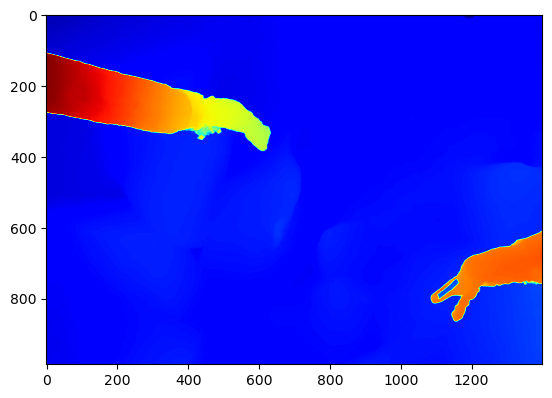

In [21]:
plt.imshow(disparity, cmap='jet')